<a href="https://colab.research.google.com/github/Vshivaram/DataScienceEcosystem/blob/main/FINALPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [73]:
 #DATA COLLECTION
# Install requests for making HTTP requests to the SpaceX API
!pip install requests

# Install pandas for data manipulation and analysis
!pip install pandas

# Install numpy for numerical operations
!pip install numpy

In [74]:
# Import requests for making HTTP requests to the SpaceX API
import requests

# Import pandas for data manipulation and creating dataframes
import pandas as pd

# Import numpy for numerical operations and handling missing values
import numpy as np

# Import datetime for handling date and time data
import datetime

# Configure pandas to display all columns of a dataframe
pd.set_option('display.max_columns', None)

# Configure pandas to display the full content of each column
pd.set_option('display.max_colwidth', None)

In [75]:
# Define a function to get the booster version from the rocket ID
def getBoosterVersion(data):
    # Initialize an empty list to store booster versions
    BoosterVersion = []
    for x in data['rocket']:
        if x:  # Check if rocket ID exists
            response = requests.get("https://api.spacexdata.com/v4/rockets/"+str(x)).json()
            BoosterVersion.append(response['name'])  # Append booster name to the list
    return BoosterVersion  # Return the list for global use

# Define a function to get launch site details from the launchpad ID
def getLaunchSite(data):
    # Initialize lists for launch site details
    Longitude = []
    Latitude = []
    LaunchSite = []
    for x in data['launchpad']:
        if x:  # Check if launchpad ID exists
            response = requests.get("https://api.spacexdata.com/v4/launchpads/"+str(x)).json()
            Longitude.append(response['longitude'])  # Append longitude
            Latitude.append(response['latitude'])    # Append latitude
            LaunchSite.append(response['name'])      # Append launch site name
    return Longitude, Latitude, LaunchSite  # Return lists for global use

# Define a function to get payload details from the payload ID
def getPayloadData(data):
    # Initialize lists for payload details
    PayloadMass = []
    Orbit = []
    for load in data['payloads']:
        if load:  # Check if payload ID exists
            response = requests.get("https://api.spacexdata.com/v4/payloads/"+load).json()
            PayloadMass.append(response['mass_kg'])  # Append payload mass
            Orbit.append(response['orbit'])          # Append orbit
    return PayloadMass, Orbit  # Return lists for global use

# Define a function to get core details from the core ID
def getCoreData(data):
    # Initialize lists for core details
    Block = []
    ReusedCount = []
    Serial = []
    Outcome = []
    Flights = []
    GridFins = []
    Reused = []
    Legs = []
    LandingPad = []
    for core in data['cores']:
        if core['core'] is not None:  # Check if core ID exists
            response = requests.get("https://api.spacexdata.com/v4/cores/"+core['core']).json()
            Block.append(response['block'])          # Append core block number
            ReusedCount.append(response['reuse_count'])  # Append reuse count
            Serial.append(response['serial'])        # Append core serial
        else:
            Block.append(None)                       # Append None for missing core
            ReusedCount.append(None)
            Serial.append(None)
        Outcome.append(str(core['landing_success'])+' '+str(core['landing_type']))  # Append landing outcome
        Flights.append(core['flight'])              # Append number of flights
        GridFins.append(core['gridfins'])           # Append gridfins usage
        Reused.append(core['reused'])               # Append reused status
        Legs.append(core['legs'])                   # Append legs usage
        LandingPad.append(core['landpad'])          # Append landing pad ID
    return Block, ReusedCount, Serial, Outcome, Flights, GridFins, Reused, Legs, LandingPad  # Return lists

In [76]:
# Define the SpaceX API URL for past launches
spacex_url = "https://api.spacexdata.com/v4/launches/past"

# Make a GET request to fetch the data
response = requests.get(spacex_url)

# Check the response status code (200 indicates success)
print(response.status_code)

# Optionally, print the raw response content to inspect the JSON data
print(response.content)

200
b'[{"fairings":{"reused":false,"recovery_attempt":false,"recovered":false,"ships":[]},"links":{"patch":{"small":"https://images2.imgbox.com/94/f2/NN6Ph45r_o.png","large":"https://images2.imgbox.com/5b/02/QcxHUb5V_o.png"},"reddit":{"campaign":null,"launch":null,"media":null,"recovery":null},"flickr":{"small":[],"original":[]},"presskit":null,"webcast":"https://www.youtube.com/watch?v=0a_00nJ_Y88","youtube_id":"0a_00nJ_Y88","article":"https://www.space.com/2196-spacex-inaugural-falcon-1-rocket-lost-launch.html","wikipedia":"https://en.wikipedia.org/wiki/DemoSat"},"static_fire_date_utc":"2006-03-17T00:00:00.000Z","static_fire_date_unix":1142553600,"net":false,"window":0,"rocket":"5e9d0d95eda69955f709d1eb","success":false,"failures":[{"time":33,"altitude":null,"reason":"merlin engine failure"}],"details":"Engine failure at 33 seconds and loss of vehicle","crew":[],"ships":[],"capsules":[],"payloads":["5eb0e4b5b6c3bb0006eeb1e1"],"launchpad":"5e9e4502f5090995de566f86","flight_number":1,"

In [77]:
# Define the URL for the static JSON file
static_json_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/API_call_spacex_api.json'

# Make a GET request to fetch the static JSON data
response = requests.get(static_json_url)

# Verify the response status code (should be 200)
print(response.status_code)

200


In [78]:
# Decode the response content as JSON
data_json = response.json()

# Convert JSON to a pandas DataFrame using json_normalize
data = pd.json_normalize(data_json)

# Display the first 5 rows of the DataFrame
print(data.head())

       static_fire_date_utc  static_fire_date_unix    tbd    net  window  \
0  2006-03-17T00:00:00.000Z           1.142554e+09  False  False     0.0   
1                      None                    NaN  False  False     0.0   
2                      None                    NaN  False  False     0.0   
3  2008-09-20T00:00:00.000Z           1.221869e+09  False  False     0.0   
4                      None                    NaN  False  False     0.0   

                     rocket  success  \
0  5e9d0d95eda69955f709d1eb    False   
1  5e9d0d95eda69955f709d1eb    False   
2  5e9d0d95eda69955f709d1eb    False   
3  5e9d0d95eda69955f709d1eb     True   
4  5e9d0d95eda69955f709d1eb     True   

                                                                                                                                                                                details  \
0                                                                                                                  

In [79]:
# Select relevant columns: rocket, payloads, launchpad, cores, flight_number, date_utc
data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]

# Remove rows with multiple cores (Falcon Heavy launches) or multiple payloads
data = data[data['cores'].map(len) == 1]
data = data[data['payloads'].map(len) == 1]

# Extract single values from cores and payloads lists
data['cores'] = data['cores'].map(lambda x: x[0])
data['payloads'] = data['payloads'].map(lambda x: x[0])

# Convert date_utc to datetime and extract the date (ignoring time)
data['date'] = pd.to_datetime(data['date_utc']).dt.date

# Restrict launches to those on or before November 13, 2020
data = data[data['date'] <= datetime.date(2020, 11, 13)]

In [80]:
# Initialize global variables to store extracted data
BoosterVersion = []
PayloadMass = []
Orbit = []
LaunchSite = []
Outcome = []
Flights = []
GridFins = []
Reused = []
Legs = []
LandingPad = []
Block = []
ReusedCount = []
Serial = []
Longitude = []
Latitude = []

In [81]:
# Call getBoosterVersion to populate BoosterVersion list
BoosterVersion = getBoosterVersion(data)
print(BoosterVersion[0:5])  # Display first 5 booster versions

# Call getLaunchSite to populate LaunchSite, Longitude, and Latitude lists
Longitude, Latitude, LaunchSite = getLaunchSite(data)

# Call getPayloadData to populate PayloadMass and Orbit lists
PayloadMass, Orbit = getPayloadData(data)

# Call getCoreData to populate core-related lists
Block, ReusedCount, Serial, Outcome, Flights, GridFins, Reused, Legs, LandingPad = getCoreData(data)

['Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 1', 'Falcon 9']


In [82]:
# Create a dictionary with all extracted data
launch_dict = {
    'FlightNumber': list(data['flight_number']),
    'Date': list(data['date']),
    'BoosterVersion': BoosterVersion,
    'PayloadMass': PayloadMass,
    'Orbit': Orbit,
    'LaunchSite': LaunchSite,
    'Outcome': Outcome,
    'Flights': Flights,
    'GridFins': GridFins,
    'Reused': Reused,
    'Legs': Legs,
    'LandingPad': LandingPad,
    'Block': Block,
    'ReusedCount': ReusedCount,
    'Serial': Serial,
    'Longitude': Longitude,
    'Latitude': Latitude
}

# Create a pandas DataFrame from the dictionary
data_falcon9 = pd.DataFrame(launch_dict)

# Display the first 5 rows of the DataFrame
print(data_falcon9.head())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit  \
0             1  2006-03-24       Falcon 1         20.0   LEO   
1             2  2007-03-21       Falcon 1          NaN   LEO   
2             4  2008-09-28       Falcon 1        165.0   LEO   
3             5  2009-07-13       Falcon 1        200.0   LEO   
4             6  2010-06-04       Falcon 9          NaN   LEO   

        LaunchSite    Outcome  Flights  GridFins  Reused   Legs LandingPad  \
0  Kwajalein Atoll  None None        1     False   False  False       None   
1  Kwajalein Atoll  None None        1     False   False  False       None   
2  Kwajalein Atoll  None None        1     False   False  False       None   
3  Kwajalein Atoll  None None        1     False   False  False       None   
4     CCSFS SLC 40  None None        1     False   False  False       None   

   Block  ReusedCount    Serial   Longitude   Latitude  
0    NaN            0  Merlin1A  167.743129   9.047721  
1    NaN            0  Mer

In [83]:
# Filter the DataFrame to keep only Falcon 9 launches
data_falcon9 = data_falcon9[data_falcon9['BoosterVersion'] != 'Falcon 1']

# Display the first 5 rows to verify
print(data_falcon9.head())

   FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
4             6  2010-06-04       Falcon 9          NaN   LEO  CCSFS SLC 40   
5             8  2012-05-22       Falcon 9        525.0   LEO  CCSFS SLC 40   
6            10  2013-03-01       Falcon 9        677.0   ISS  CCSFS SLC 40   
7            11  2013-09-29       Falcon 9        500.0    PO   VAFB SLC 4E   
8            12  2013-12-03       Falcon 9       3170.0   GTO  CCSFS SLC 40   

       Outcome  Flights  GridFins  Reused   Legs LandingPad  Block  \
4    None None        1     False   False  False       None    1.0   
5    None None        1     False   False  False       None    1.0   
6    None None        1     False   False  False       None    1.0   
7  False Ocean        1     False   False  False       None    1.0   
8    None None        1     False   False  False       None    1.0   

   ReusedCount Serial   Longitude   Latitude  
4            0  B0003  -80.577366  28.561857  
5         

In [84]:
# Reset the FlightNumber column to sequential integers
data_falcon9.loc[:, 'FlightNumber'] = list(range(1, data_falcon9.shape[0] + 1))

# Display the DataFrame to verify
print(data_falcon9)

    FlightNumber        Date BoosterVersion  PayloadMass Orbit    LaunchSite  \
4              1  2010-06-04       Falcon 9          NaN   LEO  CCSFS SLC 40   
5              2  2012-05-22       Falcon 9        525.0   LEO  CCSFS SLC 40   
6              3  2013-03-01       Falcon 9        677.0   ISS  CCSFS SLC 40   
7              4  2013-09-29       Falcon 9        500.0    PO   VAFB SLC 4E   
8              5  2013-12-03       Falcon 9       3170.0   GTO  CCSFS SLC 40   
..           ...         ...            ...          ...   ...           ...   
89            86  2020-09-03       Falcon 9      15600.0  VLEO    KSC LC 39A   
90            87  2020-10-06       Falcon 9      15600.0  VLEO    KSC LC 39A   
91            88  2020-10-18       Falcon 9      15600.0  VLEO    KSC LC 39A   
92            89  2020-10-24       Falcon 9      15600.0  VLEO  CCSFS SLC 40   
93            90  2020-11-05       Falcon 9       3681.0   MEO  CCSFS SLC 40   

        Outcome  Flights  GridFins  Reu

In [85]:
# Calculate the mean of the PayloadMass column
payload_mass_mean = data_falcon9['PayloadMass'].mean()

# Replace NaN values in PayloadMass with the mean
data_falcon9['PayloadMass'] = data_falcon9['PayloadMass'].replace(np.nan, payload_mass_mean)

# Check for remaining missing values
print(data_falcon9.isnull().sum())

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
dtype: int64


In [86]:
# Export the DataFrame to a CSV file without the index
data_falcon9.to_csv('dataset_part_1.csv', index=False)

In [87]:
# Install beautifulsoup4 for parsing HTML content
!pip3 install beautifulsoup4

# Install requests for making HTTP requests to fetch the webpage
!pip3 install requests

In [88]:
# Import sys for system-specific parameters and functions
import sys

# Import requests for making HTTP requests
import requests

# Import BeautifulSoup from bs4 for parsing HTML content
from bs4 import BeautifulSoup

# Import re for regular expressions (not used in the provided code but included for potential text processing)
import re

# Import unicodedata for normalizing text (used in get_mass function)
import unicodedata

# Import pandas for creating and manipulating dataframes
import pandas as pd

In [89]:
# Function to extract date and time from a table cell
def date_time(table_cells):
    """
    Returns the date and time from an HTML table cell.
    Input: table_cells - the element of a table data cell
    Output: List containing date and time as strings
    """
    return [data_time.strip() for data_time in list(table_cells.strings)][0:2]

# Function to extract booster version from a table cell
def booster_version(table_cells):
    """
    Returns the booster version from an HTML table cell.
    Input: table_cells - the element of a table data cell
    Output: String containing the booster version
    """
    out = ''.join([booster_version for i, booster_version in enumerate(table_cells.strings) if i % 2 == 0][0:-1])
    return out

# Function to extract landing status from a table cell
def landing_status(table_cells):
    """
    Returns the landing status from an HTML table cell.
    Input: table_cells - the element of a table data cell
    Output: String containing the landing status
    """
    out = [i for i in table_cells.strings][0]
    return out

# Function to extract payload mass from a table cell
def get_mass(table_cells):
    """
    Returns the payload mass in kg from an HTML table cell.
    Input: table_cells - the element of a table data cell
    Output: String containing the payload mass (or 0 if not found)
    """
    mass = unicodedata.normalize("NFKD", table_cells.text).strip()
    if mass:
        mass.find("kg")
        new_mass = mass[0:mass.find("kg") + 2] if "kg" in mass else "0"
    else:
        new_mass = "0"
    return new_mass

# Function to extract column names from table headers
def extract_column_from_header(row):
    """
    Returns the cleaned column name from an HTML table header cell.
    Input: row - the element of a table header cell
    Output: String containing the cleaned column name
    """
    if row.br:
        row.br.extract()  # Remove <br> tags
    if row.a:
        row.a.extract()   # Remove <a> tags
    if row.sup:
        row.sup.extract() # Remove <sup> tags
    colunm_name = ' '.join(row.contents).strip()  # Join contents and strip whitespace
    # Filter out digit-only or empty names
    if not colunm_name.isdigit() and colunm_name:
        return colunm_name
    return None

In [90]:
# Define the URL for the Wikipedia page snapshot
static_url = "https://en.wikipedia.org/w/index.php?title=List_of_Falcon_9_and_Falcon_Heavy_launches&oldid=1027686922"

# Perform an HTTP GET request to fetch the page
response = requests.get(static_url)

# Verify the response status code (200 indicates success)
print(response.status_code)

200


In [91]:
# Create a BeautifulSoup object to parse the HTML content
soup = BeautifulSoup(response.text, 'html.parser')

# Print the page title to verify successful parsing
print(soup.title.string)

List of Falcon 9 and Falcon Heavy launches - Wikipedia


In [92]:
# Find all tables with class 'wikitable plainrowheaders collapsible'
html_tables = soup.find_all('table', class_='wikitable plainrowheaders collapsible')

# Select the third table (index 2) which contains the launch records
first_launch_table = html_tables[2]

# Extract column names from the table headers
column_names = []
for th in first_launch_table.find_all('th'):
    name = extract_column_from_header(th)
    if name is not None and len(name) > 0:
        column_names.append(name)

# Print the extracted column names to verify
print(column_names)

['Flight No.', 'Date and time ( )', 'Launch site', 'Payload', 'Payload mass', 'Orbit', 'Customer', 'Launch outcome']


In [93]:
# Initialize a dictionary with column names as keys
launch_dict = dict.fromkeys(column_names)

# Remove the irrelevant column 'Date and time ( )'
del launch_dict['Date and time ( )']

# Initialize dictionary values as empty lists
launch_dict['Flight No.'] = []
launch_dict['Launch site'] = []
launch_dict['Payload'] = []
launch_dict['Payload mass'] = []
launch_dict['Orbit'] = []
launch_dict['Customer'] = []
launch_dict['Launch outcome'] = []
# Add new columns for additional data
launch_dict['Version Booster'] = []
launch_dict['Booster landing'] = []
launch_dict['Date'] = []
launch_dict['Time'] = []

# Parse each table and extract launch records
extracted_row = 0
for table_number, table in enumerate(soup.find_all('table', class_="wikitable plainrowheaders collapsible")):
    for rows in table.find_all("tr"):
        # Check if the row has a flight number (indicating a launch record)
        if rows.th and rows.th.string and rows.th.string.strip().isdigit():
            flight_number = rows.th.string.strip()
            flag = True
        else:
            flag = False
        # Get table data cells
        row = rows.find_all('td')
        # Process the row if it contains a valid flight number
        if flag:
            extracted_row += 1
            # Append Flight Number
            launch_dict['Flight No.'].append(flight_number)

            # Extract Date and Time
            datatimelist = date_time(row[0])
            launch_dict['Date'].append(datatimelist[0].strip(','))
            launch_dict['Time'].append(datatimelist[1])

            # Extract Booster Version
            bv = booster_version(row[1])
            if not bv and row[1].a and row[1].a.string:
                bv = row[1].a.string
            launch_dict['Version Booster'].append(bv)

            # Extract Launch Site
            launch_site = row[2].a.string if row[2].a else None
            launch_dict['Launch site'].append(launch_site)

            # Extract Payload
            payload = row[3].a.string if row[3].a else None
            launch_dict['Payload'].append(payload)

            # Extract Payload Mass
            payload_mass = get_mass(row[4])
            launch_dict['Payload mass'].append(payload_mass)

            # Extract Orbit
            orbit = row[5].a.string if row[5].a else None
            launch_dict['Orbit'].append(orbit)

            # Extract Customer
            customer = row[6].a.string if row[6].a else None
            launch_dict['Customer'].append(customer)

            # Extract Launch Outcome
            launch_outcome = list(row[7].strings)[0] if row[7].strings else None
            launch_dict['Launch outcome'].append(launch_outcome)

            # Extract Booster Landing
            booster_landing = landing_status(row[8])
            launch_dict['Booster landing'].append(booster_landing)

# Create a DataFrame from the dictionary
df = pd.DataFrame({key: pd.Series(value) for key, value in launch_dict.items()})

# Display the first 5 rows of the DataFrame to verify
print(df.head())

  Flight No. Launch site                               Payload Payload mass  \
0          1       CCAFS  Dragon Spacecraft Qualification Unit            0   
1          2       CCAFS                                Dragon            0   
2          3       CCAFS                                Dragon       525 kg   
3          4       CCAFS                          SpaceX CRS-1     4,700 kg   
4          5       CCAFS                          SpaceX CRS-2     4,877 kg   

  Orbit Customer Launch outcome   Version Booster Booster landing  \
0   LEO   SpaceX      Success\n  F9 v1.07B0003.18         Failure   
1   LEO     NASA        Success  F9 v1.07B0004.18         Failure   
2   LEO     NASA        Success  F9 v1.07B0005.18    No attempt\n   
3   LEO     NASA      Success\n  F9 v1.07B0006.18      No attempt   
4   LEO     NASA      Success\n  F9 v1.07B0007.18    No attempt\n   

              Date   Time  
0      4 June 2010  18:45  
1  8 December 2010  15:43  
2      22 May 2012  07:44 

In [94]:
# Export the DataFrame to a CSV file without the index
df.to_csv('spacex_web_scraped.csv', index=False)

In [95]:
# Import pandas if not already imported
import pandas as pd

# Assuming df is the DataFrame from the web scraping notebook

# Question 1: Number of launches per site
launch_site_counts = df['Launch site'].value_counts()
print("Number of launches per site:")
print(launch_site_counts)

# Question 2: Number of launches per orbit
orbit_counts = df['Orbit'].value_counts()
print("\nNumber of launches per orbit:")
print(orbit_counts)

# Question 3: Number of mission outcomes per orbit type (using 'Booster landing' for landing outcomes)
mission_outcome_per_orbit = df.groupby(['Orbit', 'Booster landing']).size().unstack(fill_value=0)
print("\nNumber of mission outcomes per orbit type:")
print(mission_outcome_per_orbit)

# Question 4: Create a landing outcome label from 'Booster landing' column
df['LandingOutcome'] = df['Booster landing'].apply(
    lambda x: 'Success' if 'Success' in str(x) else 'Failure'
)
print("\nDataFrame with LandingOutcome column:")
print(df[['Booster landing', 'LandingOutcome']].head())

# Optionally, save the updated DataFrame
df.to_csv('spacex_web_scraped_updated.csv', index=False)

Number of launches per site:
Launch site
CCAFS             40
KSC               33
Cape Canaveral    20
VAFB              16
CCSFS             12
Name: count, dtype: int64

Number of launches per orbit:
Orbit
LEO            67
GTO            33
SSO             7
Polar           7
MEO             3
HEO             2
Polar orbit     1
Sub-orbital     1
Name: count, dtype: int64

Number of mission outcomes per orbit type:
Booster landing  Controlled  Failure  Failure   No attempt  No attempt\n  \
Orbit                                                                      
GTO                       1        2         0          11             1   
HEO                       1        0         0           0             0   
LEO                       2        8         1           3             2   
MEO                       0        0         0           1             0   
Polar                     1        0         0           2             0   
Polar orbit               0        0         

In [96]:
# Import pandas if not already imported
import pandas as pd

# Assuming data_falcon9 is the DataFrame from the first notebook
# Count launches from CCAFS SLC 40
ccafs_slc40_launches = data_falcon9[data_falcon9['LaunchSite'] == 'CCAFS SLC 40'].shape[0]

# Display the result
print(f"Number of launches from CCAFS SLC 40: {ccafs_slc40_launches}")


# Calculate the number of successful launches (where Outcome contains "True")
successful_launches = data_falcon9[data_falcon9['Outcome'].str.contains('True', na=False)].shape[0]

# Calculate the total number of launches
total_launches = data_falcon9.shape[0]

# Calculate the success rate as a percentage
success_rate = (successful_launches / total_launches) * 100 if total_launches > 0 else 0

# Round to the nearest integer for comparison with options
success_rate_rounded = round(success_rate)

# Display the result
print(f"Success rate: {success_rate_rounded}%")

# Count launches to geosynchronous orbit (GTO)
gto_launches = data_falcon9[data_falcon9['Orbit'] == 'GTO'].shape[0]

# Display the result
print(f"Number of launches to geosynchronous orbit (GTO): {gto_launches}")

# Count launches with successful drone ship landings (Outcome = "True ASDS")
drone_ship_success = data_falcon9[data_falcon9['Outcome'] == 'True ASDS'].shape[0]

# Display the result
print(f"Number of successful drone ship landings: {drone_ship_success}")

Number of launches from CCAFS SLC 40: 0
Success rate: 67%
Number of launches to geosynchronous orbit (GTO): 27
Number of successful drone ship landings: 41


In [97]:
# Install sqlalchemy version 1.3.9 for database connectivity
!pip install sqlalchemy==1.3.9

# Install ipython-sql for running SQL queries in Jupyter
!pip install ipython-sql

# Install prettytable for better table formatting in SQL output
!pip install ipython-sql prettytable

# Install pandas quietly (for data manipulation)
!pip install -q pandas

  Using cached SQLAlchemy-1.3.9-cp311-cp311-linux_x86_64.whl
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.41
    Uninstalling SQLAlchemy-2.0.41:
      Successfully uninstalled SQLAlchemy-2.0.41
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.3.9 which is incompatible.
langchain 0.3.26 requires SQLAlchemy<3,>=1.4, but you have sqlalchemy 1.3.9 which is incompatible.
  Using cached sqlalchemy-2.0.41-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.6 kB)
Using cached sqlalchemy-2.0.41-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.3 MB)
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 1.3.9
    Uninstalling SQLAlchemy-1.3.9:
      Successfully uninstalled SQLAlchemy-1.3.9


In [98]:
# Load the SQL extension to run SQL queries directly
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [99]:
# Import sqlite3 for database operations and csv for handling CSV files
import csv, sqlite3

# Import prettytable for formatting SQL output
import prettytable
prettytable.DEFAULT = 'DEFAULT'

# Create a connection to the SQLite database
con = sqlite3.connect("my_data1.db")
cur = con.cursor()

# Connect the SQL magic to the SQLite database
%sql sqlite:///my_data1.db

In [100]:
# Import pandas for reading and loading the CSV
import pandas as pd

# Read the SpaceX dataset from the provided URL
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")

# Load the DataFrame into the SQLite database as table SPACEXTBL
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False, method="multi")

101

In [101]:
# Drop the table SPACEXTABLE if it exists to avoid conflicts
%sql DROP TABLE IF EXISTS SPACEXTABLE;

# Create a new table SPACEXTABLE with non-null Date rows from SPACEXTBL
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.
 * sqlite:///my_data1.db
Done.


[]

In [102]:
# Select distinct launch sites from the SPACEXTABLE
%sql SELECT DISTINCT "Launch_Site" FROM SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


In [103]:
#Select 5 records where Launch_Site starts with 'CCA'
%sql SELECT * FROM SPACEXTABLE WHERE "Launch_Site" LIKE 'CCA%' LIMIT 5;

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [104]:
#Sum the Payload_Mass__kg_ for launches where Customer is NASA (CRS)
%sql SELECT SUM("Payload_Mass__kg_") FROM SPACEXTABLE WHERE "Customer" = 'NASA (CRS)';

 * sqlite:///my_data1.db
Done.


"SUM(""Payload_Mass__kg_"")"
45596


In [105]:
#Calculate the average Payload_Mass__kg_ for booster version F9 v1.1
%sql SELECT AVG("Payload_Mass__kg_") FROM SPACEXTABLE WHERE "Booster_Version" = 'F9 v1.1';

 * sqlite:///my_data1.db
Done.


"AVG(""Payload_Mass__kg_"")"
2928.4


In [106]:
#Find the earliest Date where Landing_Outcome is a successful ground pad landing
%sql SELECT MIN("Date") FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (ground pad)';

 * sqlite:///my_data1.db
Done.


"MIN(""Date"")"
2015-12-22


In [107]:
#Select Booster_Version for successful drone ship landings with Payload_Mass__kg_ between 4000 and 6000
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "Landing_Outcome" = 'Success (drone ship)' AND "Payload_Mass__kg_" BETWEEN 4000 AND 6000;

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 FT B1022
F9 FT B1026
F9 FT B1021.2
F9 FT B1031.2


In [108]:
#Count successful and failure outcomes based on Landing_Outcome
%sql SELECT "Landing_Outcome", COUNT(*) as Outcome_Count FROM SPACEXTABLE GROUP BY "Landing_Outcome";

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Outcome_Count
Controlled (ocean),5
Failure,3
Failure (drone ship),5
Failure (parachute),2
No attempt,21
No attempt,1
Precluded (drone ship),1
Success,38
Success (drone ship),14
Success (ground pad),9


In [109]:
 #Select Booster_Version where Payload_Mass__kg_ equals the maximum payload mass
%sql SELECT "Booster_Version" FROM SPACEXTABLE WHERE "Payload_Mass__kg_" = (SELECT MAX("Payload_Mass__kg_") FROM SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


Booster_Version
F9 B5 B1048.4
F9 B5 B1049.4
F9 B5 B1051.3
F9 B5 B1056.4
F9 B5 B1048.5
F9 B5 B1051.4
F9 B5 B1049.5
F9 B5 B1060.2
F9 B5 B1058.3
F9 B5 B1051.6


In [110]:
#Select specified columns for failed drone ship landings in 2015
%sql SELECT SUBSTR("Date", 6, 2) AS Month, "Landing_Outcome", "Booster_Version", "Launch_Site" \
     FROM SPACEXTABLE \
     WHERE "Landing_Outcome" = 'Failure (drone ship)' AND SUBSTR("Date", 0, 5) = '2015';

 * sqlite:///my_data1.db
Done.


Month,Landing_Outcome,Booster_Version,Launch_Site
01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


In [111]:
%sql SELECT "Landing_Outcome", COUNT(*) AS Outcome_Count \
     FROM SPACEXTABLE \
     WHERE "Date" BETWEEN '2010-06-04' AND '2017-03-20' \
     GROUP BY "Landing_Outcome" \
     ORDER BY COUNT(*) DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Outcome_Count
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


In [112]:
# Install pandas for data manipulation
!pip install pandas

# Install numpy for numerical operations
!pip install numpy

# Install seaborn for advanced visualizations
!pip install seaborn

# Install matplotlib for plotting
!pip install matplotlib

In [113]:
# Import pandas for data manipulation and analysis
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib.pyplot for creating plots
import matplotlib.pyplot as plt

# Import seaborn for statistical visualizations
import seaborn as sns

In [114]:
# Read the SpaceX dataset from the provided URL
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Display the first 5 rows to verify
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


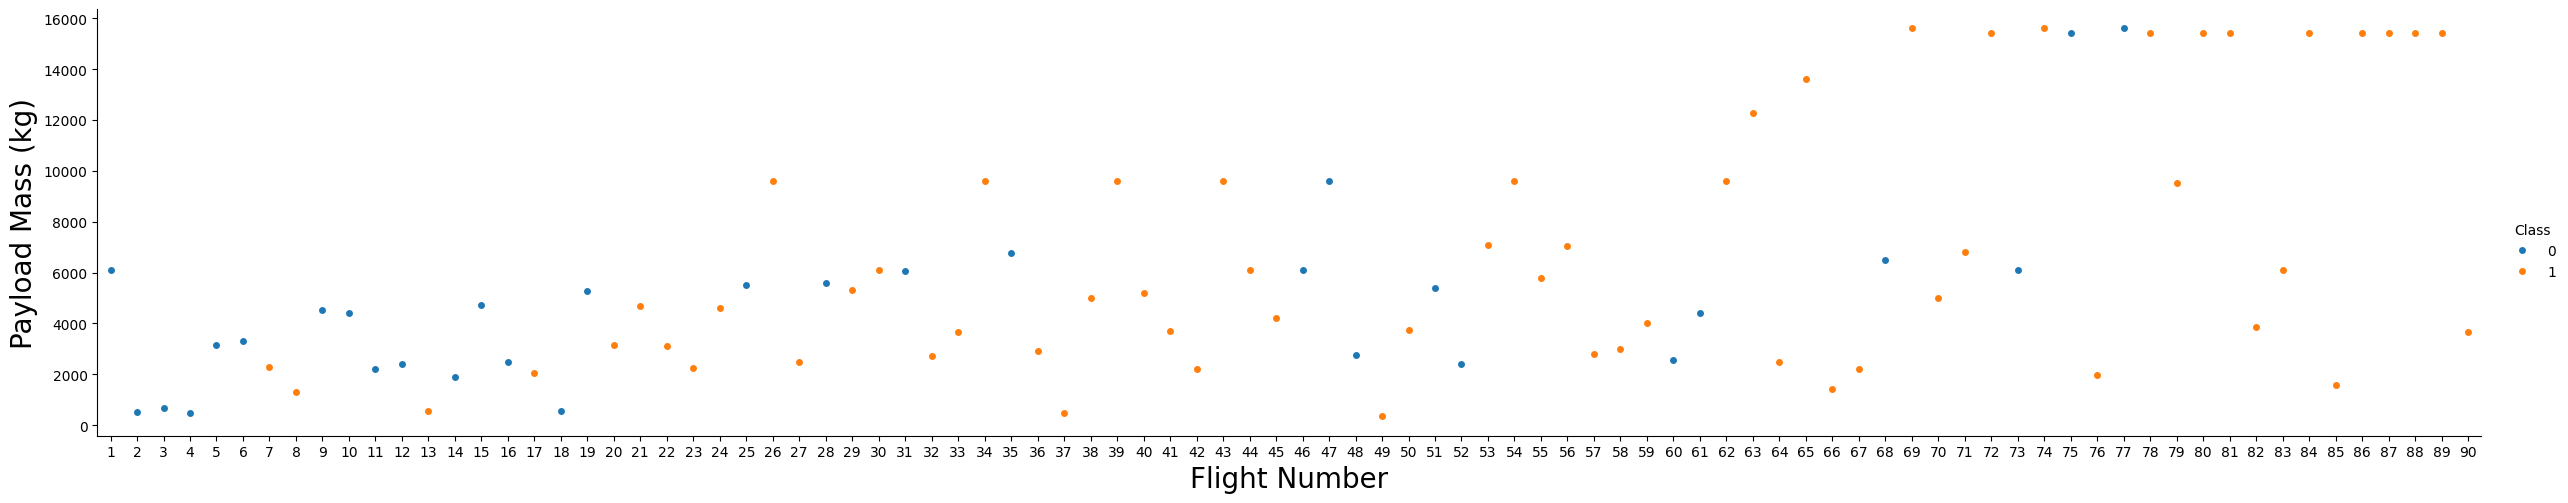

In [115]:
# Create a scatter plot with FlightNumber vs. PayloadMass, colored by Class
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.show()

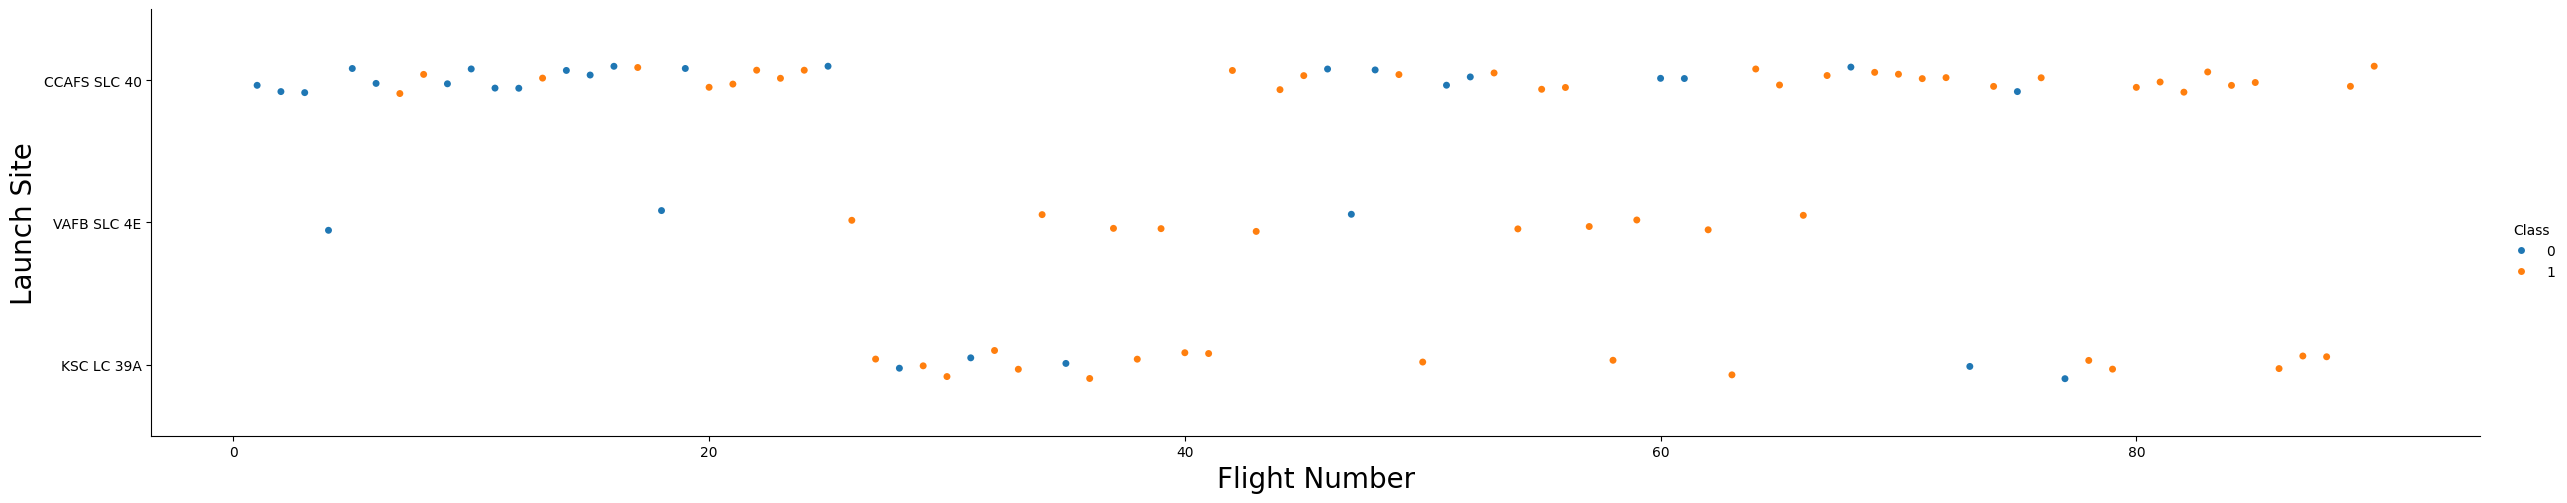

In [116]:
# Create a scatter plot with FlightNumber vs. LaunchSite, colored by Class
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

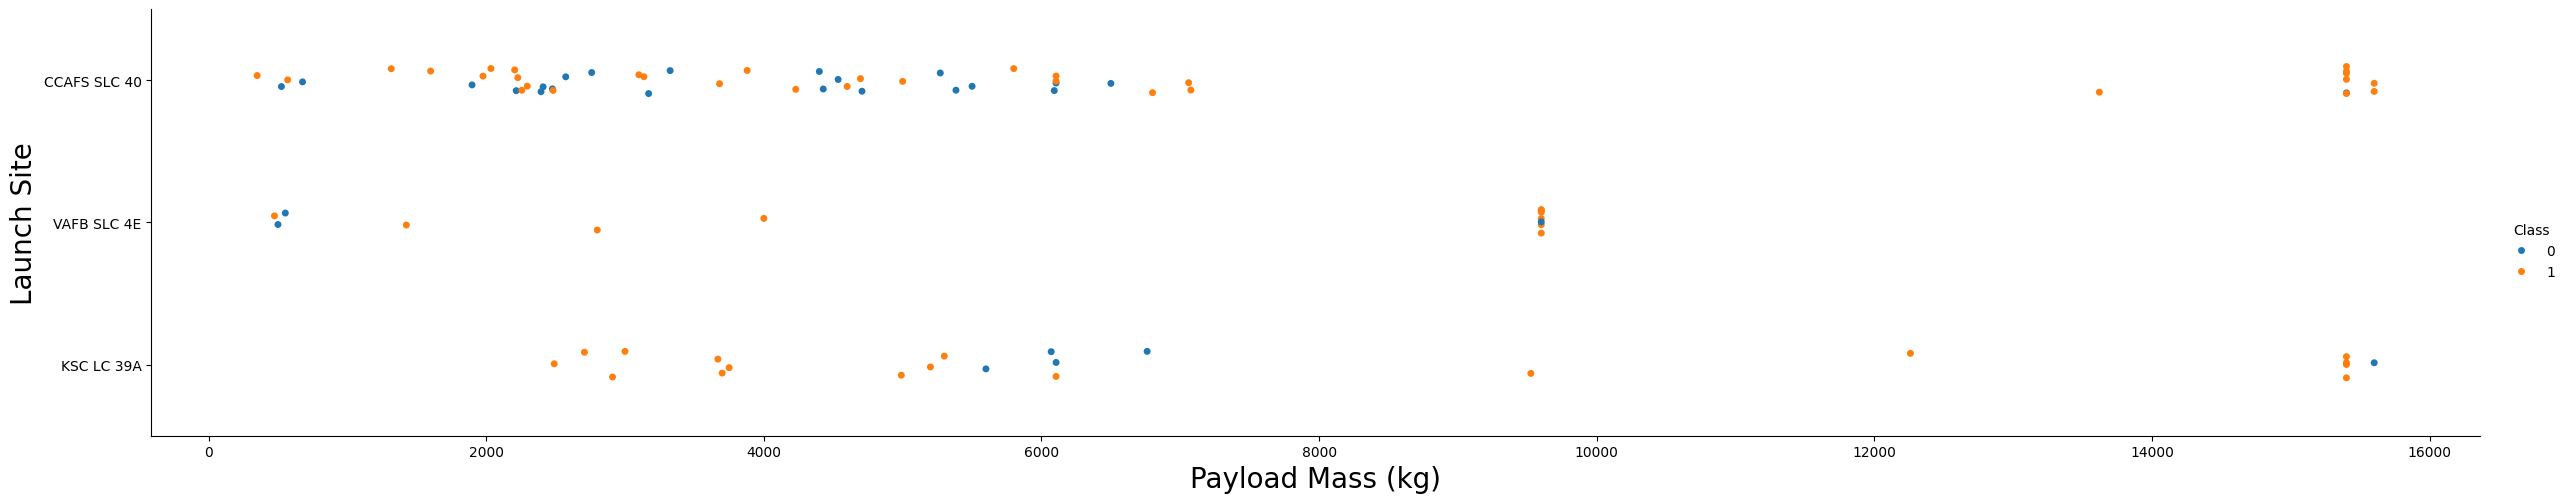

In [117]:
# Create a scatter plot with PayloadMass vs. LaunchSite, colored by Class
sns.catplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

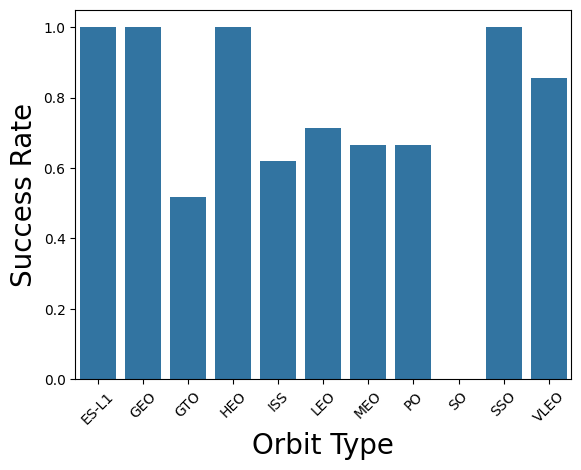

In [118]:
# Group by Orbit and calculate the mean of Class (success rate)
success_rate_by_orbit = df.groupby('Orbit')['Class'].mean().reset_index()

# Create a bar plot
sns.barplot(x='Orbit', y='Class', data=success_rate_by_orbit)
plt.xlabel("Orbit Type", fontsize=20)
plt.ylabel("Success Rate", fontsize=20)
plt.xticks(rotation=45)
plt.show()

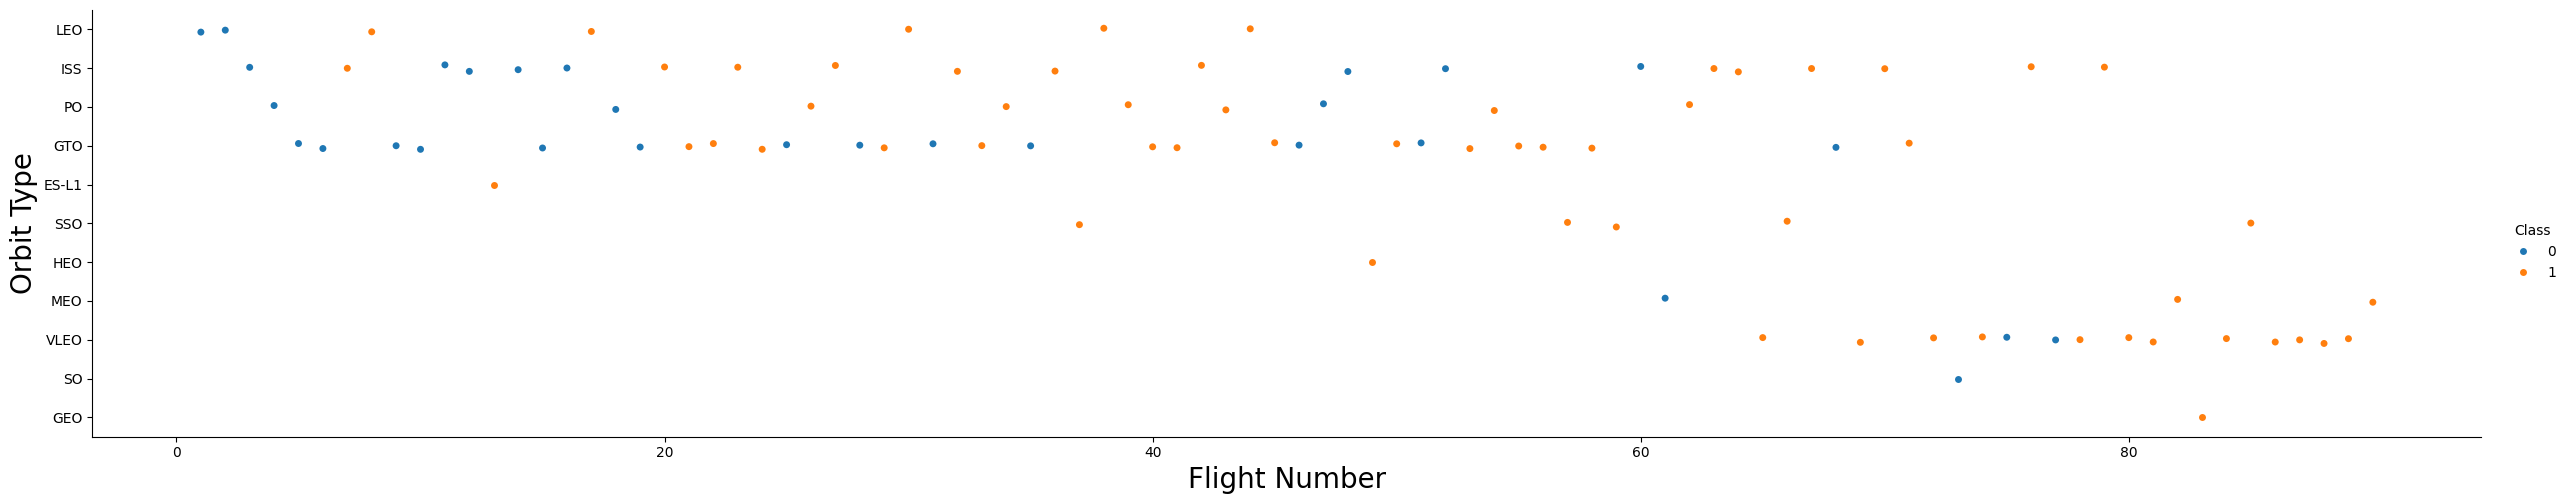

In [119]:
# Create a scatter plot with FlightNumber vs. Orbit, colored by Class
sns.catplot(x="FlightNumber", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

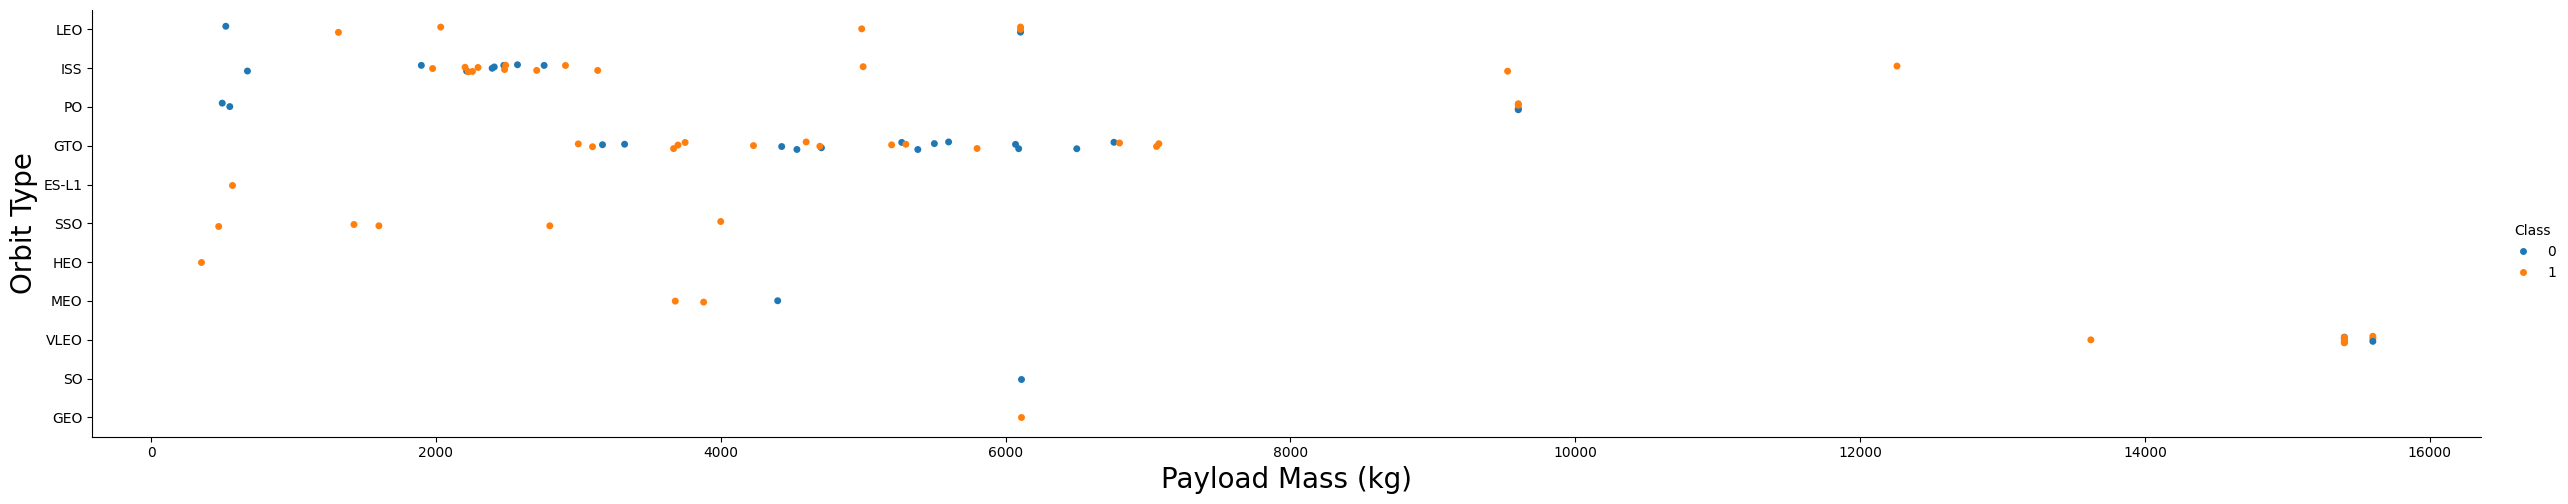

In [120]:
# Create a scatter plot with PayloadMass vs. Orbit, colored by Class
sns.catplot(x="PayloadMass", y="Orbit", hue="Class", data=df, aspect=5)
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.show()

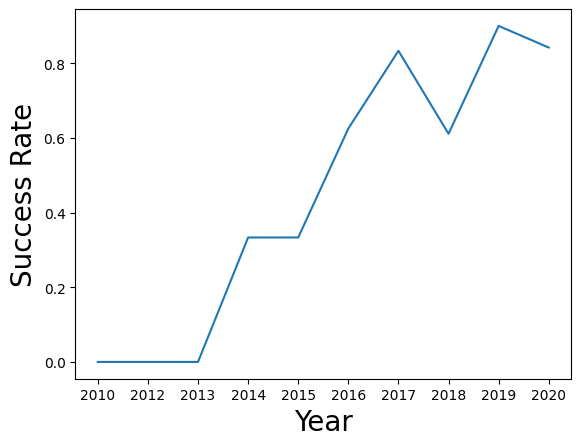

In [121]:
# Function to extract year from Date
year = []
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

# Extract years and add to DataFrame
df['Year'] = Extract_year(df['Date'])

# Group by Year and calculate mean success rate
success_rate_by_year = df.groupby('Year')['Class'].mean().reset_index()

# Create a line plot
sns.lineplot(x='Year', y='Class', data=success_rate_by_year)
plt.xlabel("Year", fontsize=20)
plt.ylabel("Success Rate", fontsize=20)
plt.show()

In [122]:
# Create dummy variables for categorical columns
features_one_hot = pd.get_dummies(df[['Orbit', 'LaunchSite', 'LandingPad', 'Serial']], columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Combine with original features
features_one_hot = pd.concat([df[['FlightNumber', 'PayloadMass', 'Flights', 'GridFins', 'Reused', 'Legs', 'Block', 'ReusedCount']], features_one_hot], axis=1)

# Display the first 5 rows
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [123]:
# Cast all columns in features_one_hot to float64
features_one_hot = features_one_hot.astype('float64')

# Display the first 5 rows to verify
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [124]:
# Export the DataFrame to CSV
features_one_hot.to_csv('dataset_part_3.csv', index=False)

In [125]:
# Install folium for interactive maps
!pip3 install folium

# Install wget for downloading files
!pip3 install wget

# Install pandas for data manipulation
!pip3 install pandas

In [126]:
# Import folium for creating interactive maps
import folium

# Import wget for downloading the dataset
import wget

# Import pandas for data manipulation
import pandas as pd

# Import folium plugins for marker clustering, mouse position, and custom icons
from folium.plugins import MarkerCluster
from folium.plugins import MousePosition
from folium.features import DivIcon

In [127]:
# Download the SpaceX dataset with geographic coordinates
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')

# Load the dataset into a pandas DataFrame
spacex_df = pd.read_csv(spacex_csv_file)

In [128]:
# Select relevant columns: Launch Site, Lat, Long, class
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]

# Group by Launch Site to get the first occurrence of coordinates
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()

# Select only Launch Site, Lat, and Long for mapping
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]

# Display the launch sites DataFrame
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [129]:
# Define the center coordinates (NASA Johnson Space Center)
nasa_coordinate = [29.559684888503615, -95.0830971930759]

# Initialize a Folium map with zoom level 10
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

# Add a circle and marker for NASA Johnson Space Center as an example
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
marker = folium.map.Marker(
    nasa_coordinate,
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'NASA JSC',
    )
)
site_map.add_child(circle)
site_map.add_child(marker)

In [130]:
# Re-initialize the map with a broader zoom level to show all launch sites
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

# Iterate through each launch site in launch_sites_df
for index, row in launch_sites_df.iterrows():
    # Define coordinates for the launch site
    coordinate = [row['Lat'], row['Long']]

    # Add a circle for the launch site
    circle = folium.Circle(
        coordinate,
        radius=1000,
        color='#d35400',
        fill=True
    ).add_child(folium.Popup(row['Launch Site']))

    # Add a marker with the launch site name
    marker = folium.map.Marker(
        coordinate,
        icon=DivIcon(
            icon_size=(20,20),
            icon_anchor=(0,0),
            html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % row['Launch Site'],
        )
    )

    # Add circle and marker to the map
    site_map.add_child(circle)
    site_map.add_child(marker)

# Display the map
site_map

In [131]:
# Create a MarkerCluster object
marker_cluster = MarkerCluster()

# Add marker_cluster to the map
site_map.add_child(marker_cluster)

# Define a function to assign marker colors based on class
def assign_marker_color(launch_outcome):
    return 'green' if launch_outcome == 1 else 'red'

# Apply the function to create a marker_color column
spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)

# Add a marker for each launch record
for index, record in spacex_df.iterrows():
    # Define coordinates
    coordinate = [record['Lat'], record['Long']]

    # Create a marker with custom icon color based on launch outcome
    marker = folium.Marker(
        coordinate,
        icon=folium.Icon(color='white', icon_color=record['marker_color'])
    )

    # Add the marker to the marker cluster
    marker_cluster.add_child(marker)

# Display the map
site_map

In [132]:
# Add MousePosition plugin to display coordinates
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)
site_map.add_child(mouse_position)

# Define function to calculate distance between two points
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6373.0  # Earth's radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# Example: Calculate distance from CCAFS SLC-40 to closest coastline
launch_site = launch_sites_df[launch_sites_df['Launch Site'] == 'CCAFS SLC-40']
launch_site_lat = launch_site['Lat'].iloc[0]  # 28.563197
launch_site_lon = launch_site['Long'].iloc[0]  # -80.576820

# Coordinates of closest coastline (approximated using MousePosition)
coastline_lat = 28.56367
coastline_lon = -80.57163
distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)

# Add a marker for the coastline point
distance_marker = folium.Marker(
    [coastline_lat, coastline_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_coastline),
    )
)
site_map.add_child(distance_marker)

# Draw a PolyLine between the launch site and coastline
coordinates = [[launch_site_lat, launch_site_lon], [coastline_lat, coastline_lon]]
lines = folium.PolyLine(locations=coordinates, weight=1)
site_map.add_child(lines)

# Example: Calculate distances to other proximities (e.g., city, railway, highway)
# Coordinates for a nearby city (Titusville, near CCAFS SLC-40)
city_lat = 28.61208
city_lon = -80.80756
distance_city = calculate_distance(launch_site_lat, launch_site_lon, city_lat, city_lon)
city_marker = folium.Marker(
    [city_lat, city_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_city),
    )
)
site_map.add_child(city_marker)
city_line = folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [city_lat, city_lon]], weight=1)
site_map.add_child(city_line)

# Coordinates for a nearby railway
railway_lat = 28.57205
railway_lon = -80.58528
distance_railway = calculate_distance(launch_site_lat, launch_site_lon, railway_lat, railway_lon)
railway_marker = folium.Marker(
    [railway_lat, railway_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_railway),
    )
)
site_map.add_child(railway_marker)
railway_line = folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [railway_lat, railway_lon]], weight=1)
site_map.add_child(railway_line)

# Coordinates for a nearby highway
highway_lat = 28.56230
highway_lon = -80.57067
distance_highway = calculate_distance(launch_site_lat, launch_site_lon, highway_lat, highway_lon)
highway_marker = folium.Marker(
    [highway_lat, highway_lon],
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_highway),
    )
)
site_map.add_child(highway_marker)
highway_line = folium.PolyLine(locations=[[launch_site_lat, launch_site_lon], [highway_lat, highway_lon]], weight=1)
site_map.add_child(highway_line)

# Display the map
site_map

In [142]:
# Import required libraries

import requests

# URL for the SpaceX dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"

# Download the file
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    with open("spacex_launch_dash.csv", "wb") as file:
        file.write(response.content)
    print("Dataset downloaded and saved as 'spacex_launch_dash.csv'")
else:
    print(f"Failed to download dataset. Status code: {response.status_code}")

# Verify the file
import pandas as pd
try:
    df = pd.read_csv("spacex_launch_dash.csv")
    print("Dataset columns:", df.columns.tolist())
    print(df.head())
except Exception as e:
    print(f"Error reading CSV: {e}")

import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px

# Read the SpaceX data into pandas dataframe
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[
    html.H1('SpaceX Launch Records Dashboard',
            style={'textAlign': 'center', 'color': '#503D36', 'font-size': 40}),
    # TASK 1: Add a dropdown list to enable Launch Site selection
    # The default select value is for ALL sites
    dcc.Dropdown(id='site-dropdown',
                 options=[
                     {'label': 'All Sites', 'value': 'ALL'},
                     {'label': 'CCAFS LC-40', 'value': 'CCAFS LC-40'},
                     {'label': 'VAFB SLC-4E', 'value': 'VAFB SLC-4E'},
                     {'label': 'KSC LC-39A', 'value': 'KSC LC-39A'},
                     {'label': 'CCAFS SLC-40', 'value': 'CCAFS SLC-40'}
                 ],
                 value='ALL',
                 placeholder='Select a Launch Site here',
                 searchable=True
                 ),
    html.Br(),

    # TASK 2: Add a pie chart to show the total successful launches count for all sites
    # If a specific launch site was selected, show the Success vs. Failed counts for the site
    html.Div(dcc.Graph(id='success-pie-chart')),
    html.Br(),

    html.P("Payload range (Kg):"),
    # TASK 3: Add a slider to select payload range
    dcc.RangeSlider(id='payload-slider',
                    min=0,
                    max=10000,
                    step=1000,
                    value=[min_payload, max_payload],
                    marks={i: str(i) for i in range(0, 10001, 1000)}
                    ),

    # TASK 4: Add a scatter chart to show the correlation between payload and launch success
    html.Div(dcc.Graph(id='success-payload-scatter-chart')),
])

# TASK 2: Add a callback function for `site-dropdown` as input, `success-pie-chart` as output
@app.callback(Output(component_id='success-pie-chart', component_property='figure'),
              Input(component_id='site-dropdown', component_property='value'))
def get_pie_chart(entered_site):
    if entered_site == 'ALL':
        fig = px.pie(spacex_df, values='class',
                     names='Launch Site',
                     title='Total Success Launches By All Sites')
        return fig
    else:
        filtered_df = spacex_df[spacex_df['Launch Site'] == entered_site]
        filtered_df = filtered_df.groupby(['Launch Site', 'class']).size().reset_index(name='class count')
        fig = px.pie(filtered_df, values='class count', names='class',
                     title=f'Total Success Launches for Site {entered_site}')
        return fig

# TASK 4: Add a callback function for `site-dropdown` and `payload-slider` as inputs, `success-payload-scatter-chart` as output
@app.callback(Output(component_id='success-payload-scatter-chart', component_property='figure'),
              [Input(component_id='site-dropdown', component_property='value'),
               Input(component_id='payload-slider', component_property='value')])
def scatter(entered_site, payload):
    filtered_df = spacex_df[spacex_df['Payload Mass (kg)'].between(payload[0], payload[1])]
    if entered_site == 'ALL':
        fig = px.scatter(filtered_df, x='Payload Mass (kg)', y='class',
                         color='Booster Version Category',
                         title='Payload vs. Launch Outcome for All Sites')
        return fig
    else:
        filtered_df = filtered_df[filtered_df['Launch Site'] == entered_site]
        fig = px.scatter(filtered_df, x='Payload Mass (kg)', y='class',
                         color='Booster Version Category',
                         title=f'Payload vs. Launch Outcome for Site {entered_site}')
        return fig

# Run the app
if __name__ == '__main__':
    app.run(debug=False, port=8050)

Dataset downloaded and saved as 'spacex_launch_dash.csv'
Dataset columns: ['Unnamed: 0', 'Flight Number', 'Launch Site', 'class', 'Payload Mass (kg)', 'Booster Version', 'Booster Version Category']
   Unnamed: 0  Flight Number  Launch Site  class  Payload Mass (kg)  \
0           0              1  CCAFS LC-40      0                0.0   
1           1              2  CCAFS LC-40      0                0.0   
2           2              3  CCAFS LC-40      0              525.0   
3           3              4  CCAFS LC-40      0              500.0   
4           4              5  CCAFS LC-40      0              677.0   

  Booster Version Booster Version Category  
0  F9 v1.0  B0003                     v1.0  
1  F9 v1.0  B0004                     v1.0  
2  F9 v1.0  B0005                     v1.0  
3  F9 v1.0  B0006                     v1.0  
4  F9 v1.0  B0007                     v1.0  


<IPython.core.display.Javascript object>

In [146]:
!pip install numpy
!pip install pandas
!pip install seaborn
!pip install scikit-learn

# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

In [147]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

In [148]:
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")


In [149]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [150]:

X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

In [151]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,Orbit_VLEO,LaunchSite_CCAFS SLC 40,LaunchSite_KSC LC 39A,LaunchSite_VAFB SLC 4E,LandingPad_5e9e3032383ecb267a34e7c7,LandingPad_5e9e3032383ecb554034e7c9,LandingPad_5e9e3032383ecb6bb234e7ca,LandingPad_5e9e3032383ecb761634e7cb,LandingPad_5e9e3033383ecbb9e534e7cc,Serial_B0003,Serial_B0005,Serial_B0007,Serial_B1003,Serial_B1004,Serial_B1005,Serial_B1006,Serial_B1007,Serial_B1008,Serial_B1010,Serial_B1011,Serial_B1012,Serial_B1013,Serial_B1015,Serial_B1016,Serial_B1017,Serial_B1018,Serial_B1019,Serial_B1020,Serial_B1021,Serial_B1022,Serial_B1023,Serial_B1025,Serial_B1026,Serial_B1028,Serial_B1029,Serial_B1030,Serial_B1031,Serial_B1032,Serial_B1034,Serial_B1035,Serial_B1036,Serial_B1037,Serial_B1038,Serial_B1039,Serial_B1040,Serial_B1041,Serial_B1042,Serial_B1043,Serial_B1044,Serial_B1045,Serial_B1046,Serial_B1047,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.

In [152]:
Y = data['Class'].to_numpy()

In [153]:
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

In [154]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [155]:
parameters = {"C": [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}
lr = LogisticRegression()
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ", logreg_cv.best_params_)
print("accuracy :", logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


In [156]:
logreg_accuracy = logreg_cv.score(X_test, Y_test)
print("Logistic Regression - Test Accuracy:", logreg_accuracy)

Logistic Regression - Test Accuracy: 0.8333333333333334


In [157]:
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv=10)
svm_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ", svm_cv.best_params_)
print("accuracy :", svm_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


In [158]:
svm_accuracy = svm_cv.score(X_test, Y_test)
print("SVM - Test Accuracy:", svm_accuracy)

SVM - Test Accuracy: 0.8333333333333334


In [159]:
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1, 10)],
              'max_features': ['sqrt', 'log2'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}
tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv=10)
tree_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ", tree_cv.best_params_)
print("accuracy :", tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'splitter': 'random'}
accuracy : 0.8857142857142856


In [160]:
tree_accuracy = tree_cv.score(X_test, Y_test)
print("Decision Tree - Test Accuracy:", tree_accuracy)

Decision Tree - Test Accuracy: 0.8333333333333334


In [161]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}
KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv=10)
knn_cv.fit(X_train, Y_train)
print("tuned hpyerparameters :(best parameters) ", knn_cv.best_params_)
print("accuracy :", knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


In [162]:
knn_accuracy = knn_cv.score(X_test, Y_test)
print("KNN - Test Accuracy:", knn_accuracy)

KNN - Test Accuracy: 0.8333333333333334


In [163]:
accuracies = {
    'Logistic Regression': logreg_accuracy,
    'SVM': svm_accuracy,
    'Decision Tree': tree_accuracy,
    'KNN': knn_accuracy
}
best_method = max(accuracies, key=accuracies.get)
print(f"Best performing method: {best_method} with test accuracy: {accuracies[best_method]}")

Best performing method: Logistic Regression with test accuracy: 0.8333333333333334
